In [45]:
from pathlib import Path

import pandas as pd
from torch import tensor
import matplotlib.pyplot as plt

import re

DIRECTORY = Path(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file')
DATA_PATH = DIRECTORY / 'domain_mmlu_data'


In [46]:
drop_df = pd.read_csv(DIRECTORY / 'domain_masked_wrong_answer_dropped.csv')
drop_df

,Unnamed: 0,Question,Fed_Prompt,Label,Choosed_wrong_answer,True_answer,Subject,Grade
0,0,"### Câu hỏi: Trong giờ ra chơi, A trêu đùa và ...","Trong giờ ra chơi, A trêu đùa và đánh B gây ch...",Cùng với A đánh B cho vui.,C,A,civic_education,GDCD 8
1,1,### Câu hỏi: Trên đường đi học về em nhìn thấy...,Trên đường đi học về em nhìn thấy một thanh ni...,Đạp thật nhanh về nhà.,D,B,civic_education,GDCD 8
2,2,### Câu hỏi: Câu thành ngữ: Gió chiều nào theo...,Câu thành ngữ: Gió chiều nào theo chiều ấy nói...,Không tôn trọng lẽ phải.,A,C,civic_education,GDCD 8
3,3,### Câu hỏi: Em rèn tính liêm khiết trong học ...,Em rèn tính liêm khiết trong học tập là:\nA. N...,"Làm giàu bằng chính sức lực, tài năng của mình",B,D,civic_education,GDCD 8
4,4,"### Câu hỏi: Không hám danh, hám lợi, không nh...","Không hám danh, hám lợi, không nhỏ nhen, ích k...",Khiêm tốn.,D,A,civic_education,GDCD 8
...,...,...,...,...,...,...,...,...
1192,1192,### Câu hỏi: Đọc thầm bài văn sau:\n \n CẢNH L...,Đọc thầm bài văn sau:\n \n CẢNH LÀNG DẠ\n \n M...,Đổ xuống,D,A,literature,Ngữ văn 3
1193,1193,### Câu hỏi: Đọc thầm bài văn sau:\n \n CẢNH L...,Đọc thầm bài văn sau:\n \n CẢNH LÀNG DẠ\n \n M...,Những dải sỏi cuội gồ ghề và sạch sẽ,A,C,literature,Ngữ văn 3
1194,1194,### Câu hỏi: Đọc thầm bài văn sau:\n \n CẢNH L...,Đọc thầm bài văn sau:\n \n CẢNH LÀNG DẠ\n \n M...,Khua xào xạc trước khi từ giã thân mẹ đơn sơ,D,B,literature,Ngữ văn 3
1195,1195,### Câu hỏi: Đọc thầm bài văn sau:\n \n CẢNH L...,Đọc thầm bài văn sau:\n \n CẢNH LÀNG DẠ\n \n M...,Những tàu lá vắt vẻo mềm mại như cái đuôi mèo,C,A,literature,Ngữ văn 3


In [47]:
def format_grade(text):
    result = re.sub('[^0-9]', '', text)
    return result
format_grade('Lớp 1')

'1'

In [48]:
# drop_df['Grade'] = drop_df['Grade'].apply(format_grade)
# drop_df

In [49]:
df = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\domain_mmlu_data\filtered_data_no_math\vistral_7b_mini_logging_file_domain.csv')


In [50]:
drop_df = drop_df['Grade']
df = pd.concat([df, drop_df], axis = 1)

In [51]:
df

,predict,label,score,Subject,retained,Grade
0,Can ngăn A và giúp B.,Cùng với A đánh B cho vui.,0.307692,civic_education,True,GDCD 8
1,Gọi điện cho gia đình của em đó và nhờ sự giúp...,Đèo em bé đó đến gặp công an.,0.166667,civic_education,True,GDCD 8
2,Không trung thực.,Không tôn trọng lẽ phải.,0.250000,civic_education,True,GDCD 8
3,"Làm giàu bằng chính sức lực, tài năng của mình",Nhiệt tình giúp đỡ mọi người mà không tính toá...,0.000000,civic_education,True,GDCD 8
4,Chính trực.,Khiêm tốn.,0.000000,civic_education,True,GDCD 8
...,...,...,...,...,...,...
1192,],Xà xuống,0.000000,literature,True,Ngữ văn 3
1193,],Những dải sỏi cuội dính đất,0.000000,literature,True,Ngữ văn 3
1194,Khua lách tách trong gió,Khua xào xạc trước khi từ giã thân mẹ đơn sơ,0.125000,literature,True,Ngữ văn 3
1195,],Những tàu lá vắt vẻo mềm mại như cái đuôi gà,0.000000,literature,True,Ngữ văn 3


In [52]:
# df.to_csv(DIRECTORY / 'vistral_7b_mini_logging_file_domain.csv', index = False)

In [67]:
def plot_dropped(df):
    fig, ax = plt.subplots(figsize = (30, 9))

    count = {}
    count_drop = {}
    for key in df['Grade'].unique():
        count[key] = [df[df['Grade'] == key].shape[0]]
        count_drop[key] = [df[(df['Grade'] == key) & (df['retained'] == False)].shape[0]]

    # count = pd.DataFrame.from_dict(count, orient='index')
    # count_drop = pd.DataFrame.from_dict(count_drop, orient='index')
    # plt.bar(count.index, count[0], color = 'b')
    # plt.bar(count_drop.index, count_drop[0], color = 'r')

    for grade, value in count.items():
        p = ax.bar(grade, value[0], color = 'b')
        ax.bar_label(p, label_type = 'edge')

    for grade, value in count_drop.items():
        p = ax.bar(grade, value[0], color = 'r')
        ax.bar_label(p, label_type = 'edge')

    # plt.title(f'{name}')
    # if drop_math:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}_no_math.png')
    # else:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}.png')
    plt.close()
    return fig

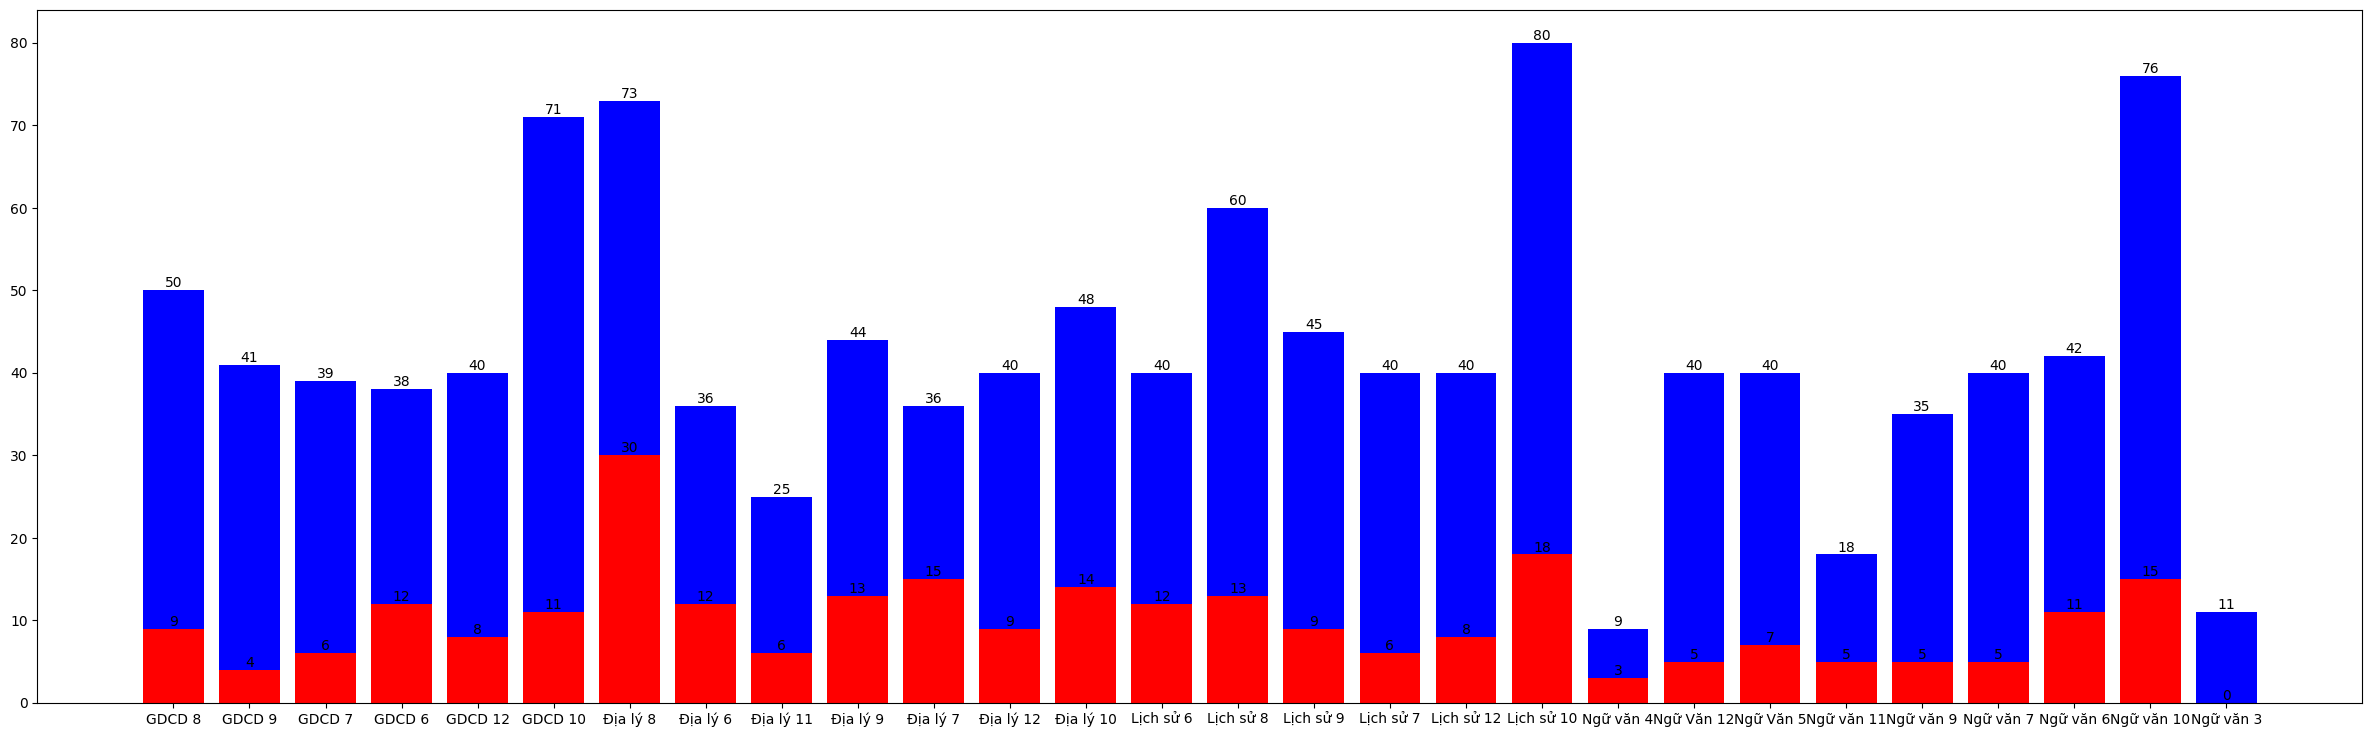

In [68]:
plot_dropped(df)